# Feature Importance Analysis — 5-model aggregation

Gradient-based feature-importance analysis aggregated across all **5 models** produced by `train_42feats_multirun.ipynb`. Outputs:

- **Mean importance ranking** (42 features, averaged across 5 models)
- **Ranking-stability** via pairwise Spearman correlations between runs
- **Class-wise importance heatmap** (mean across models)
- **Top-20 correlation heatmap** (Pearson, between input features)
- **Top-20 bar chart** and **feature-group summary**
- CSVs: `feature_importance_mean.csv`, `feature_importance_per_run.csv`, `top20_list.csv`, `top10_list.csv`

This design addresses Reviewer 3's request for genuine statistical analysis and Reviewer 2's question about inter-feature correlations.

## 1. Imports and config

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# PATHS — edit to match your Drive layout
# ------------------------------------------------------------------
CSV_PATH = '/content/drive/MyDrive/Feature Importance Analysis/one_shot_features_clean_V4.csv'
SAVE_DIR = '/content/drive/MyDrive/SavedModels/42feats_runs'
OUT_DIR  = f'{SAVE_DIR}/importance'
os.makedirs(OUT_DIR, exist_ok=True)

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
RUN_SEEDS  = [42, 123, 7, 2024, 512]
SPLIT_SEED = 42     # must match training notebook
TEST_SIZE  = 0.2
BATCH_SIZE = 64


## 2. Reload data and identical validation split
Exact same preprocessing + split as the training notebook.

In [3]:
df = pd.read_csv(CSV_PATH)
df_filled = df.copy()
numeric_columns = df.select_dtypes(include=[np.number]).columns
df_filled[numeric_columns] = (
    df_filled[numeric_columns].fillna(df_filled[numeric_columns].mean())
)

feature_cols = [c for c in df_filled.columns if c not in ('label', 'filename')]
X = df_filled[feature_cols].values
y = df_filled['label'].values

# Reuse the exact scaler and encoder saved by training notebook
scaler        = joblib.load(f'{SAVE_DIR}/scaler_42feats.joblib')
label_encoder = joblib.load(f'{SAVE_DIR}/label_encoder_42feats.joblib')
class_names   = list(label_encoder.classes_)
num_classes   = len(class_names)

X_scaled       = scaler.transform(X)
y_encoded      = label_encoder.transform(y)
y_categorical  = tf.keras.utils.to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_categorical,
    test_size=TEST_SIZE, random_state=SPLIT_SEED, stratify=y_encoded
)
y_true_idx = np.argmax(y_test, axis=1)

print(f'features : {len(feature_cols)}')
print(f'val set  : {X_test.shape}')
print(f'classes  : {class_names}')


features : 42
val set  : (1287, 42)
classes  : ['Bass', 'Clap', 'Cymbal', 'Hat', 'Kick', 'Rims', 'Snare']


## 3. Gradient-based importance functions
For each sample in the validation set we compute

$$
\text{Imp}(x_k) = \frac{1}{N}\sum_{i=1}^{N}
\left|\frac{\partial L(\mathbf{x}^{(i)}, y^{(i)})}{\partial x_k}\right|
$$

where $L$ is the categorical cross-entropy loss. We evaluate the **full** validation set (no batch-limit truncation) and additionally compute per-class importance by restricting the average to samples of each class.

In [4]:
def compute_gradients_batch(model, inputs, labels):
    """Per-sample |grad L / grad x| for one batch.
    Returns tensor of shape (batch_size, n_features).
    """
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        preds = model(inputs, training=False)
        loss  = tf.keras.losses.categorical_crossentropy(labels, preds)
    grads = tape.gradient(loss, inputs)
    return tf.abs(grads)


def importance_for_model(model, X_val, y_val, num_classes, batch=BATCH_SIZE):
    """Compute global and per-class importance for one model over the
    ENTIRE validation set (no truncation)."""
    n = X_val.shape[0]
    X_f32 = X_val.astype(np.float32)
    y_f32 = y_val.astype(np.float32)
    y_idx = np.argmax(y_val, axis=1)

    all_grads = np.empty((n, X_val.shape[1]), dtype=np.float32)
    for i in range(0, n, batch):
        xb = tf.constant(X_f32[i:i+batch])
        yb = tf.constant(y_f32[i:i+batch])
        all_grads[i:i+batch] = compute_gradients_batch(model, xb, yb).numpy()

    # Global importance
    imp_global = all_grads.mean(axis=0)

    # Per-class importance
    imp_class = np.zeros((num_classes, X_val.shape[1]), dtype=np.float32)
    for c in range(num_classes):
        mask = (y_idx == c)
        if mask.any():
            imp_class[c] = all_grads[mask].mean(axis=0)

    return imp_global, imp_class


## 4. Compute importance for each of the 5 trained models

In [5]:
imp_per_run       = np.zeros((len(RUN_SEEDS), len(feature_cols)), dtype=np.float32)
imp_class_per_run = np.zeros((len(RUN_SEEDS), num_classes, len(feature_cols)),
                             dtype=np.float32)

for i, seed in enumerate(RUN_SEEDS):
    ckpt = f'{SAVE_DIR}/run{i+1}_seed{seed}.h5'
    print(f'[{i+1}/{len(RUN_SEEDS)}] loading: {ckpt}')
    tf.keras.backend.clear_session()
    model = load_model(ckpt)
    imp_g, imp_c = importance_for_model(
        model, X_test, y_test, num_classes
    )
    imp_per_run[i]       = imp_g
    imp_class_per_run[i] = imp_c
    del model

print('\ndone.')
print(f'imp_per_run shape       : {imp_per_run.shape}')
print(f'imp_class_per_run shape : {imp_class_per_run.shape}')


[1/5] loading: /content/drive/MyDrive/SavedModels/42feats_runs/run1_seed42.h5


[2/5] loading: /content/drive/MyDrive/SavedModels/42feats_runs/run2_seed123.h5


[3/5] loading: /content/drive/MyDrive/SavedModels/42feats_runs/run3_seed7.h5


[4/5] loading: /content/drive/MyDrive/SavedModels/42feats_runs/run4_seed2024.h5


[5/5] loading: /content/drive/MyDrive/SavedModels/42feats_runs/run5_seed512.h5



done.
imp_per_run shape       : (5, 42)
imp_class_per_run shape : (5, 7, 42)


## 5. Aggregate — mean ± std across runs
Note: raw gradient magnitudes are not directly comparable across runs (different weight scales). We therefore also report a **rank-based** aggregate, which is the standard approach for cross-run feature importance.

In [6]:
# Per-run full rankings (rank 1 = most important)
ranks_per_run = np.argsort(np.argsort(-imp_per_run, axis=1), axis=1) + 1
# ranks_per_run[i, k] = rank of feature k in run i

# Mean importance and mean rank across runs
imp_mean = imp_per_run.mean(axis=0)
imp_std  = imp_per_run.std(axis=0)
rank_mean = ranks_per_run.mean(axis=0)
rank_std  = ranks_per_run.std(axis=0)

# Final ranking: sort by MEAN RANK (lower is better)
order = np.argsort(rank_mean)

importance_df = pd.DataFrame({
    'feature'      : np.array(feature_cols)[order],
    'rank_mean'    : rank_mean[order],
    'rank_std'     : rank_std[order],
    'imp_mean'     : imp_mean[order],
    'imp_std'      : imp_std[order],
}).reset_index(drop=True)

importance_df.index = importance_df.index + 1  # 1-indexed rank
importance_df.to_csv(f'{OUT_DIR}/feature_importance_mean.csv')

# Per-run full table for transparency
per_run_df = pd.DataFrame(imp_per_run.T,
                          columns=[f'run{i+1}_seed{s}' for i, s in enumerate(RUN_SEEDS)],
                          index=feature_cols)
per_run_df.to_csv(f'{OUT_DIR}/feature_importance_per_run.csv')

print('FULL RANKING (sorted by mean rank across 5 runs)\n')
print(importance_df.to_string())


FULL RANKING (sorted by mean rank across 5 runs)

           feature  rank_mean  rank_std  imp_mean   imp_std
1        onset_sum        1.0  0.000000  0.609601  0.073315
2          rms_std        2.0  0.000000  0.347636  0.036148
3        flux_mean        3.6  0.800000  0.259854  0.011308
4           mfcc03        3.8  0.748331  0.252446  0.019096
5           mfcc04        5.0  1.095445  0.230426  0.016805
6        onset_std        6.6  1.200000  0.210707  0.021690
7      contrast_b6        7.8  1.600000  0.193693  0.022898
8           mfcc02        8.2  1.939072  0.190369  0.010643
9         rms_mean        9.8  2.039608  0.179175  0.020576
10      onset_mean       11.0  3.847077  0.179779  0.015751
11          mfcc01       11.8  1.720465  0.167247  0.012024
12       onset_max       12.0  2.366432  0.165439  0.019193
13     contrast_b2       12.6  1.624808  0.162650  0.015693
14  bandwidth_mean       13.0  2.366432  0.159914  0.015646
15        zcr_mean       14.2  3.059412  0.152119 

## 6. Ranking stability — pairwise Spearman across runs
If rankings are consistent across runs, pairwise Spearman ρ will be high (typically > 0.85). This is the statistical evidence that the identified important features are not an artefact of a single run.

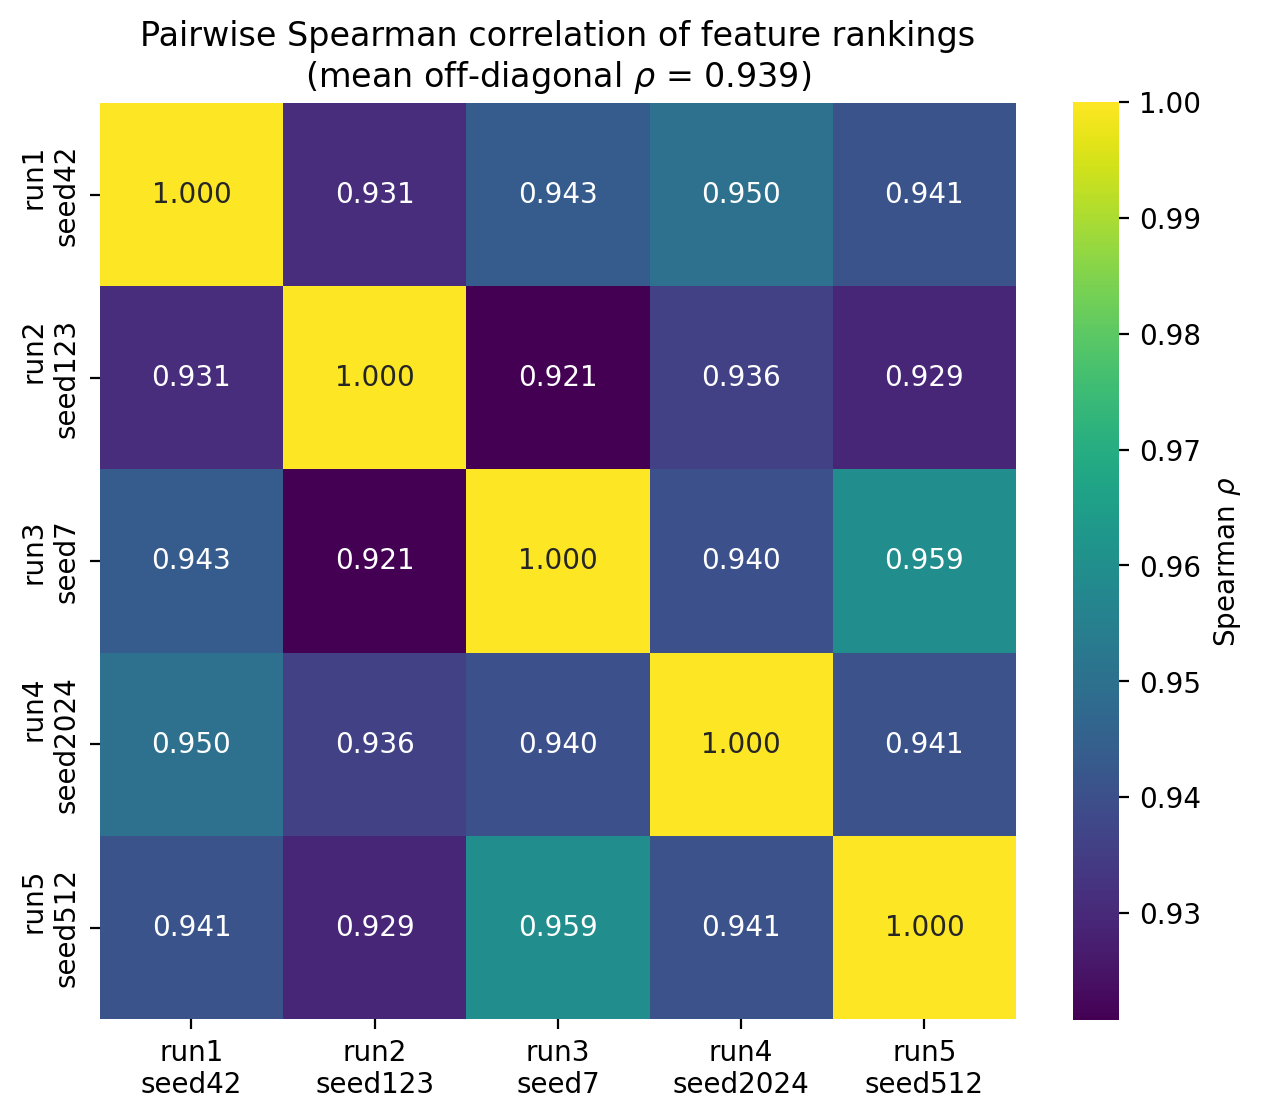

Mean off-diagonal rho : 0.9392
Min  off-diagonal rho : 0.9208
Max  off-diagonal rho : 0.9592


In [7]:
n = len(RUN_SEEDS)
rho_mat = np.ones((n, n))
for i in range(n):
    for j in range(i+1, n):
        rho, _ = spearmanr(imp_per_run[i], imp_per_run[j])
        rho_mat[i, j] = rho_mat[j, i] = rho

run_labels = [f'run{i+1}\nseed{s}' for i, s in enumerate(RUN_SEEDS)]

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=200)
sns.heatmap(rho_mat, annot=True, fmt='.3f', cmap='viridis',
            vmin=rho_mat.min(), vmax=1.0,
            xticklabels=run_labels, yticklabels=run_labels,
            cbar_kws={'label': r'Spearman $\rho$'}, ax=ax, square=True)
ax.set_title('Pairwise Spearman correlation of feature rankings\n'
             f'(mean off-diagonal $\\rho$ = {rho_mat[np.triu_indices(n, k=1)].mean():.3f})')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ranking_stability_spearman.png',
            dpi=300, bbox_inches='tight')
plt.show()

off_diag = rho_mat[np.triu_indices(n, k=1)]
print(f'Mean off-diagonal rho : {off_diag.mean():.4f}')
print(f'Min  off-diagonal rho : {off_diag.min():.4f}')
print(f'Max  off-diagonal rho : {off_diag.max():.4f}')


## 7. Top-20 features — bar chart (mean ± std across 5 models)

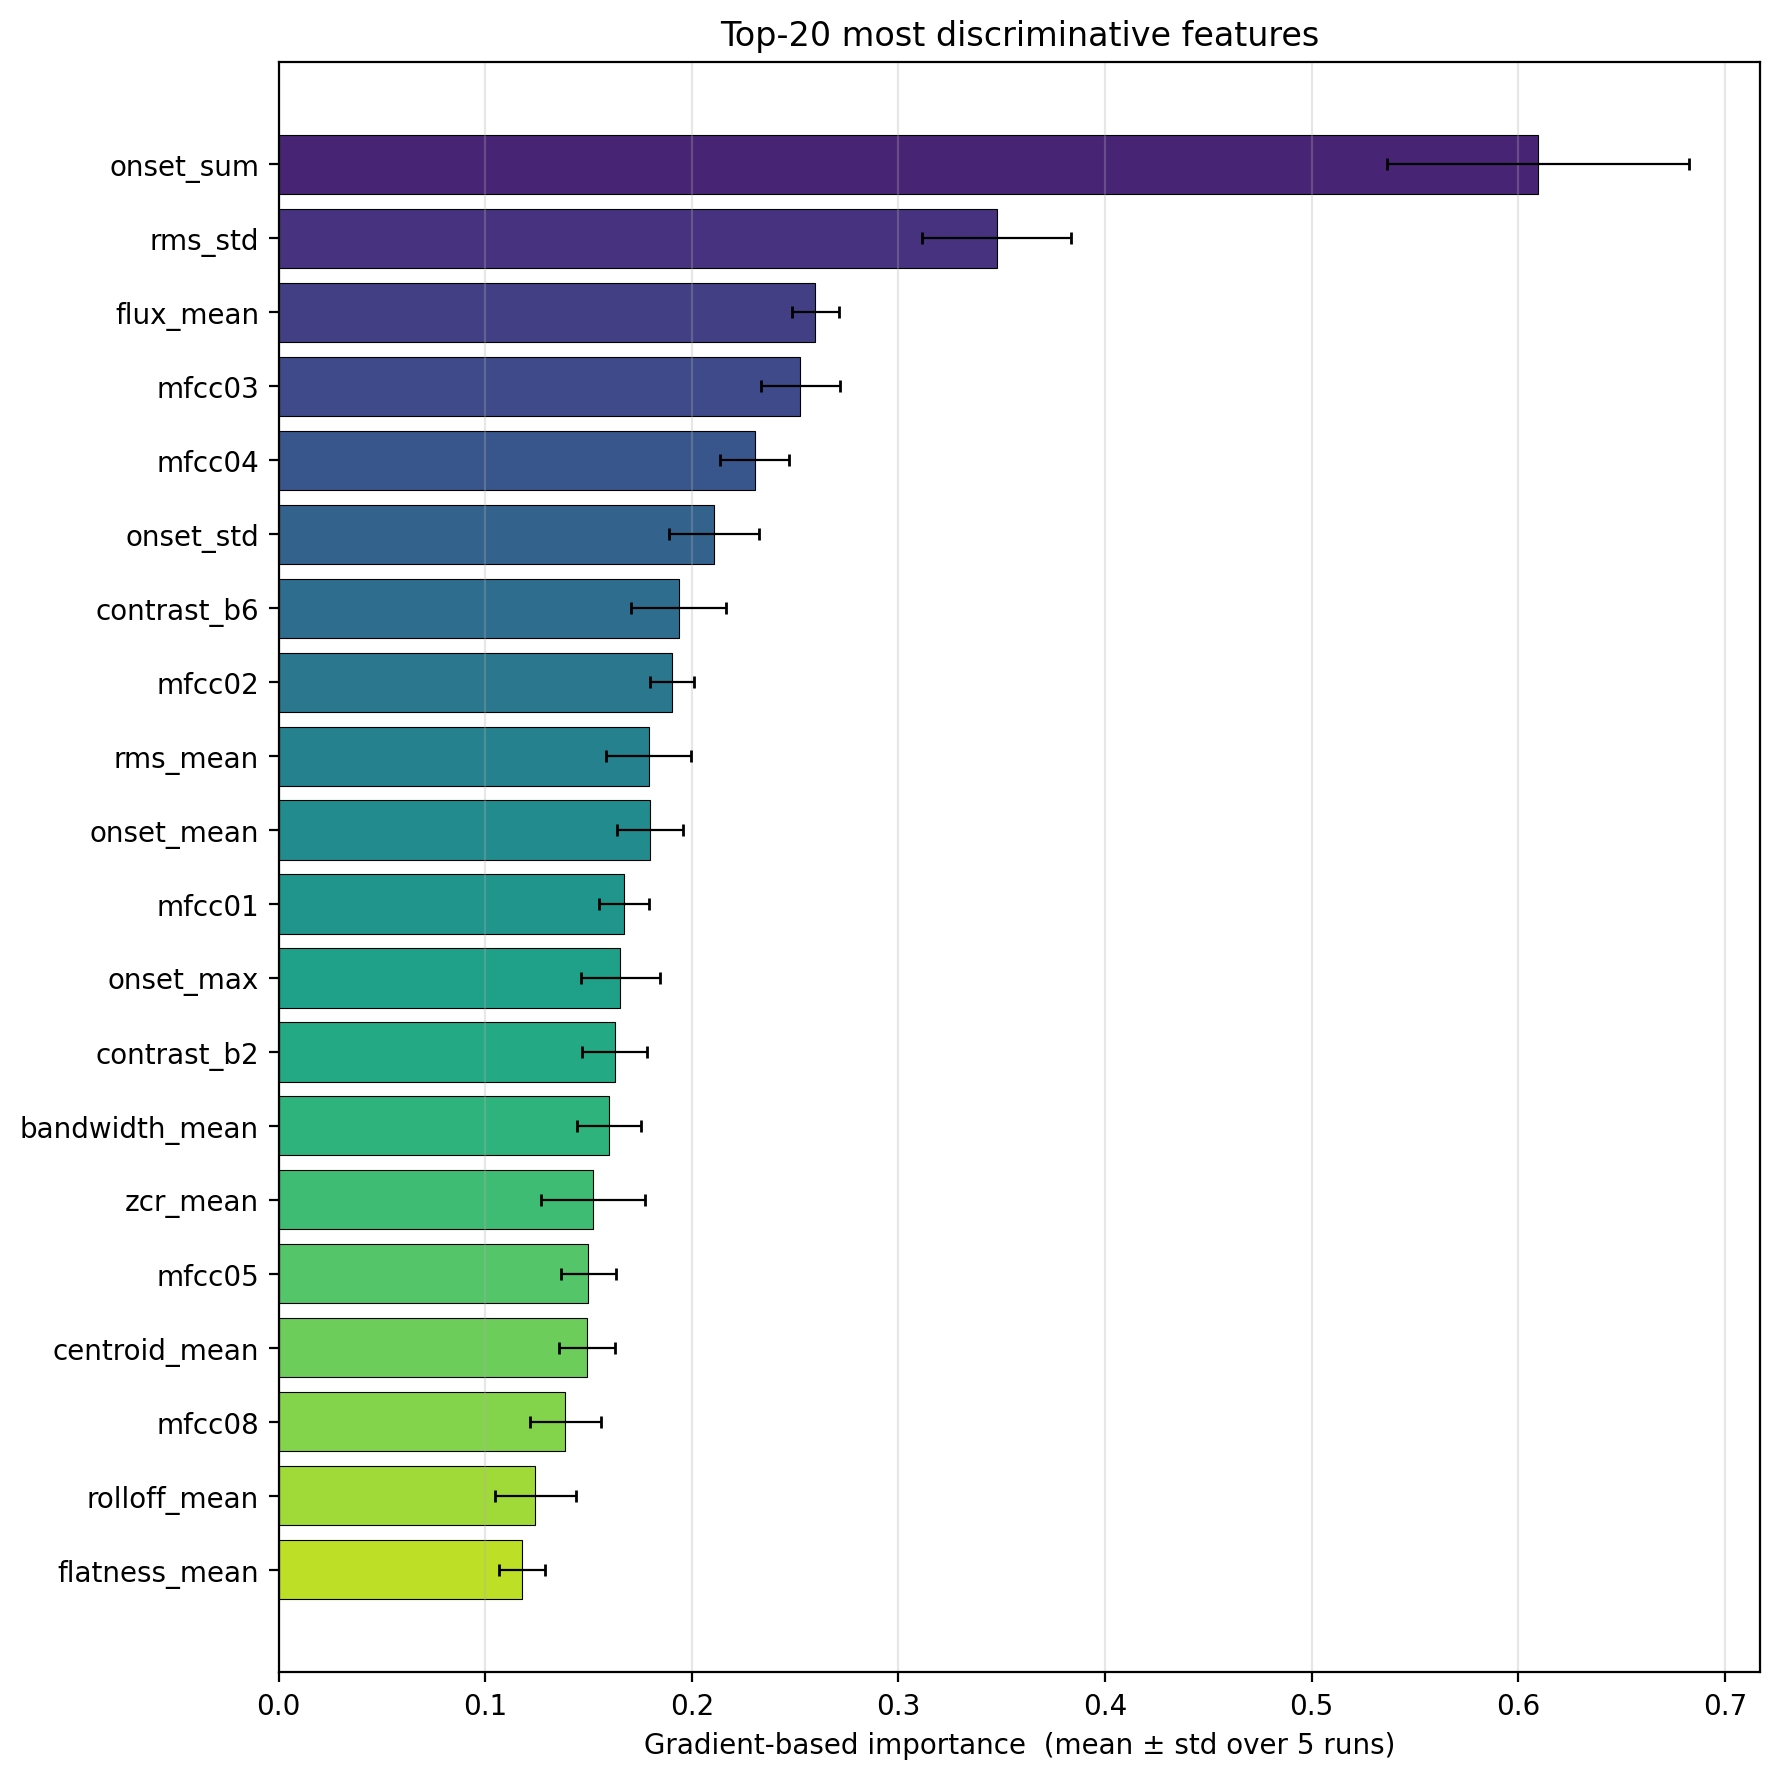

In [8]:
top20 = importance_df.head(20).copy()

fig, ax = plt.subplots(figsize=(9, 9), dpi=200)
ypos = np.arange(len(top20))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(top20)))

ax.barh(ypos, top20['imp_mean'], xerr=top20['imp_std'],
        color=colors, edgecolor='black', linewidth=0.4,
        error_kw={'ecolor': 'black', 'capsize': 2, 'lw': 0.8})
ax.set_yticks(ypos)
ax.set_yticklabels(top20['feature'])
ax.invert_yaxis()  # rank 1 at top
ax.set_xlabel('Gradient-based importance  (mean ± std over 5 runs)')
ax.set_title('Top-20 most discriminative features')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/top20_importance_bar.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 8. Class-wise importance heatmap
Average across 5 models; restricted to the top-10 features. Row-wise min-max normalised version also shown (requested by Reviewer 2 to ease cross-class comparison).

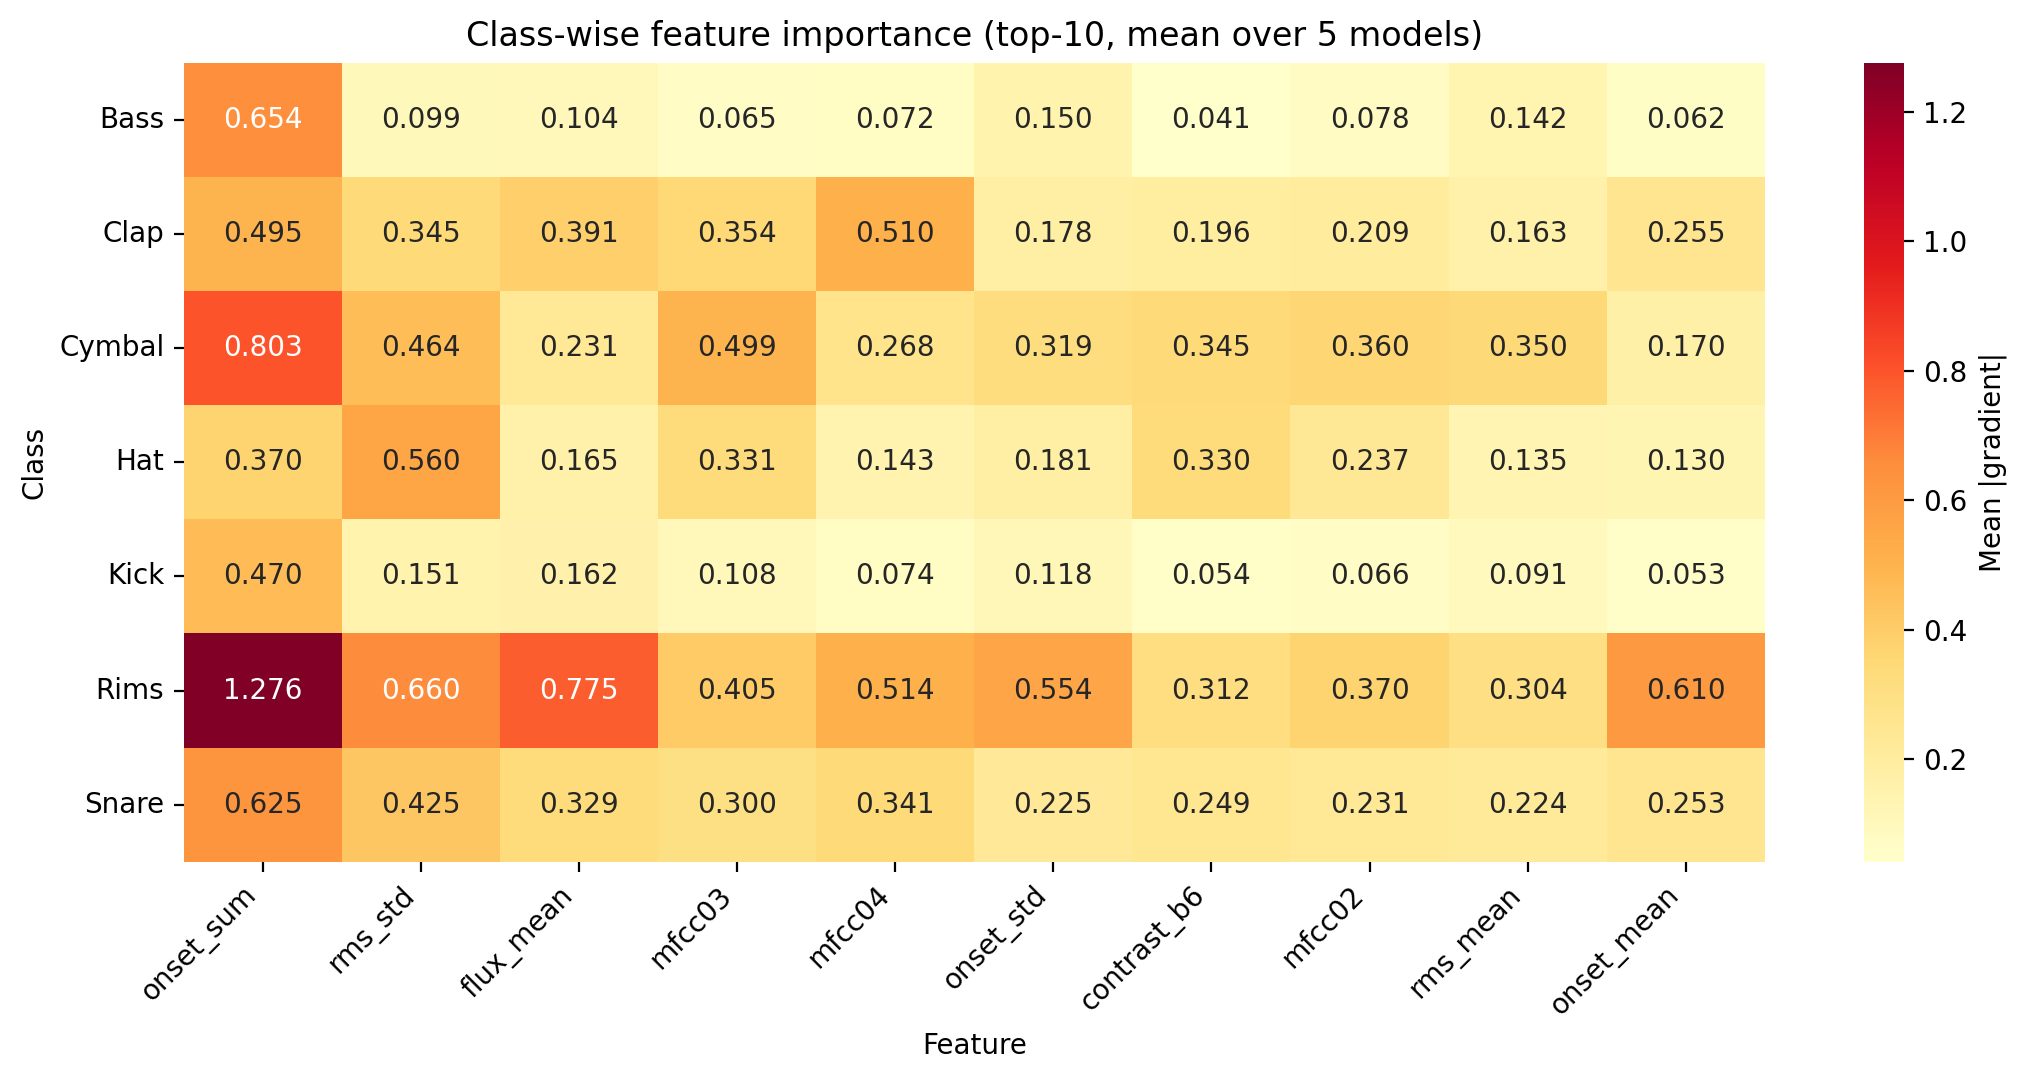

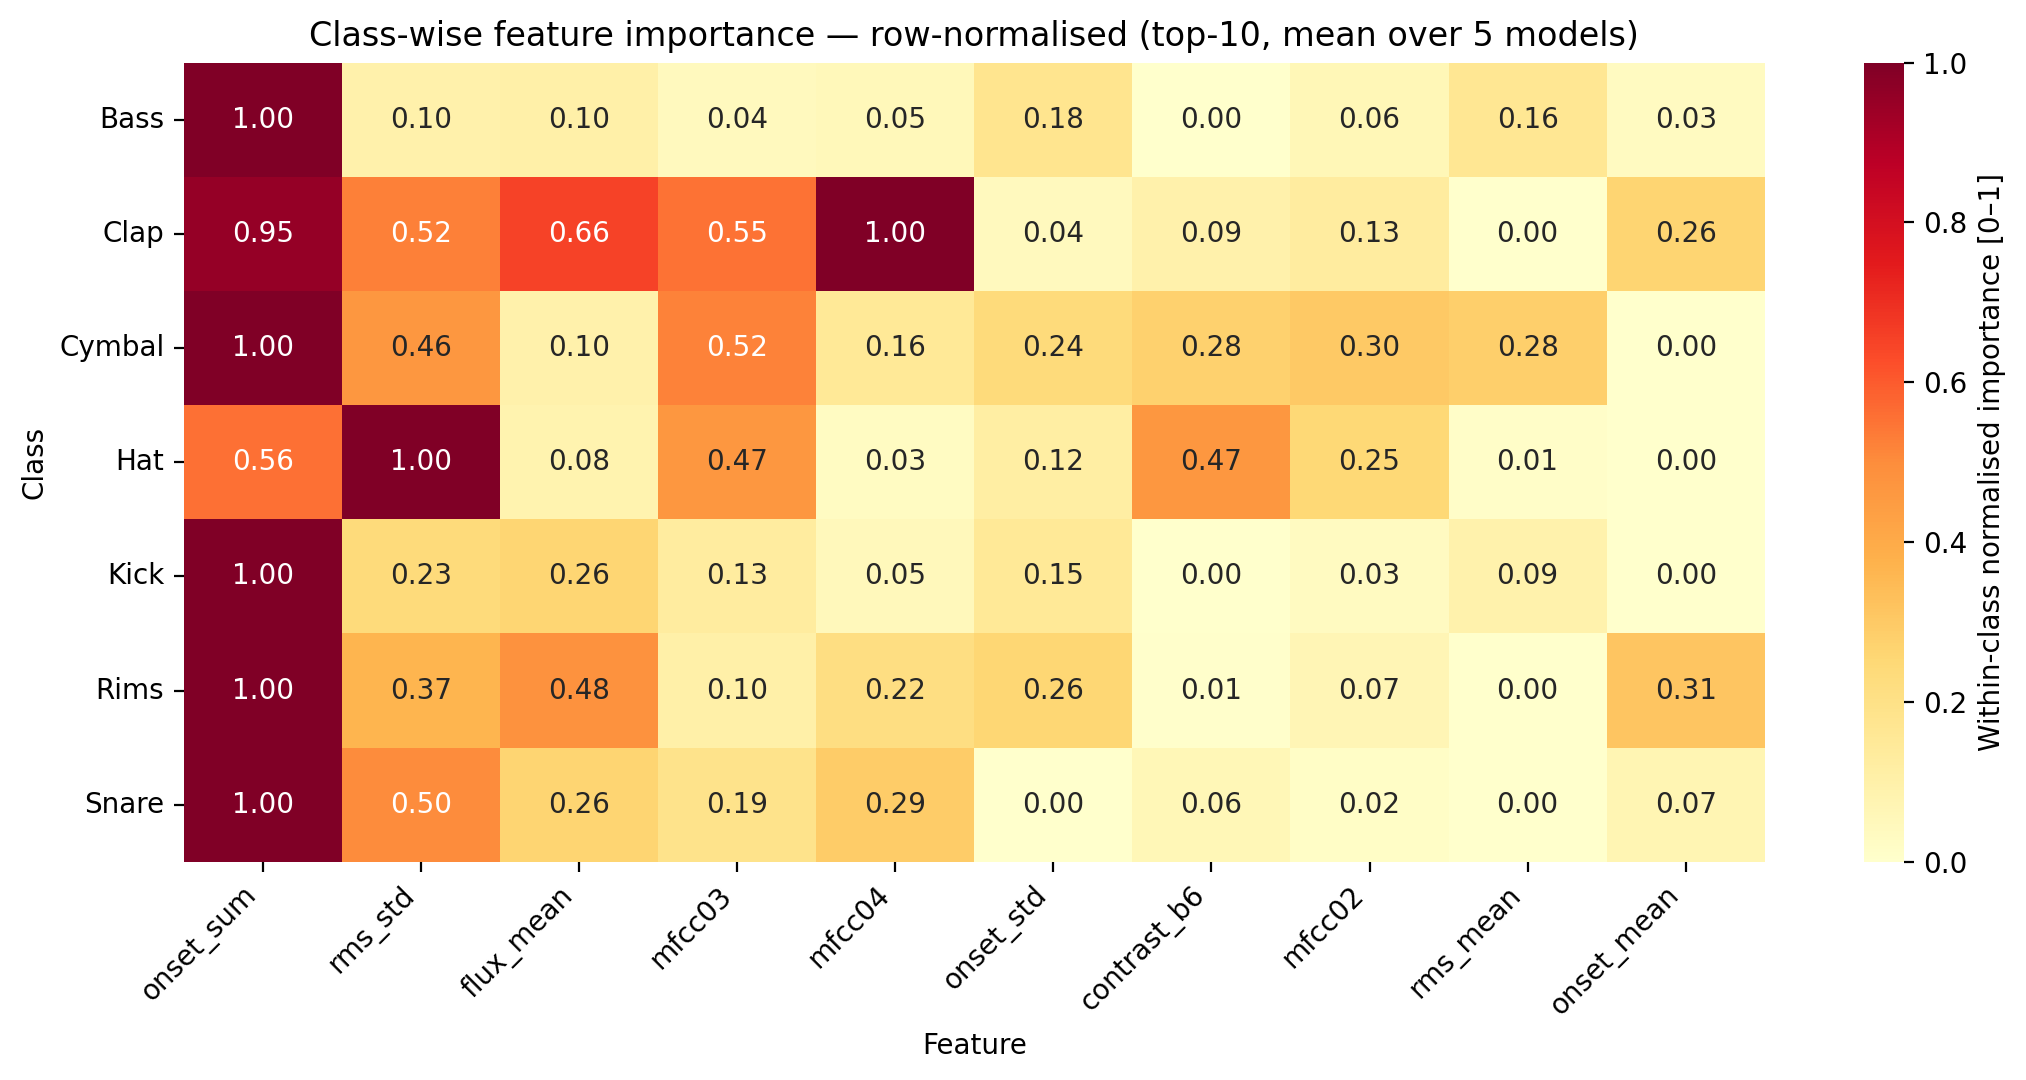

In [9]:
# Mean across runs, shape (num_classes, n_features)
imp_class_mean = imp_class_per_run.mean(axis=0)

top10_feats = importance_df.head(10)['feature'].tolist()
top10_idx   = [feature_cols.index(f) for f in top10_feats]

heat_df = pd.DataFrame(imp_class_mean[:, top10_idx],
                       index=class_names, columns=top10_feats)

# -------- Raw values --------
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=200)
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'Mean |gradient|'}, ax=ax)
ax.set_title('Class-wise feature importance (top-10, mean over 5 models)')
ax.set_xlabel('Feature')
ax.set_ylabel('Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/class_importance_raw.png',
            dpi=300, bbox_inches='tight')
plt.show()

# -------- Row-wise min-max --------
row_min = heat_df.min(axis=1).values.reshape(-1, 1)
row_max = heat_df.max(axis=1).values.reshape(-1, 1)
heat_norm = (heat_df.values - row_min) / (row_max - row_min + 1e-12)
heat_norm_df = pd.DataFrame(heat_norm, index=class_names, columns=top10_feats)

fig, ax = plt.subplots(figsize=(11, 5.5), dpi=200)
sns.heatmap(heat_norm_df, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Within-class normalised importance [0–1]'}, ax=ax)
ax.set_title('Class-wise feature importance — row-normalised '
             '(top-10, mean over 5 models)')
ax.set_xlabel('Feature')
ax.set_ylabel('Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/class_importance_rownorm.png',
            dpi=300, bbox_inches='tight')
plt.show()


## 9. Top-20 feature correlation heatmap
Reviewer 2 asked explicitly: *"Did authors check if any of the most informative features are also correlated between them?"*

High |r| among nominally-distinct features (e.g. among the four onset statistics or the two RMS statistics) is expected and will be noted in the Results section.

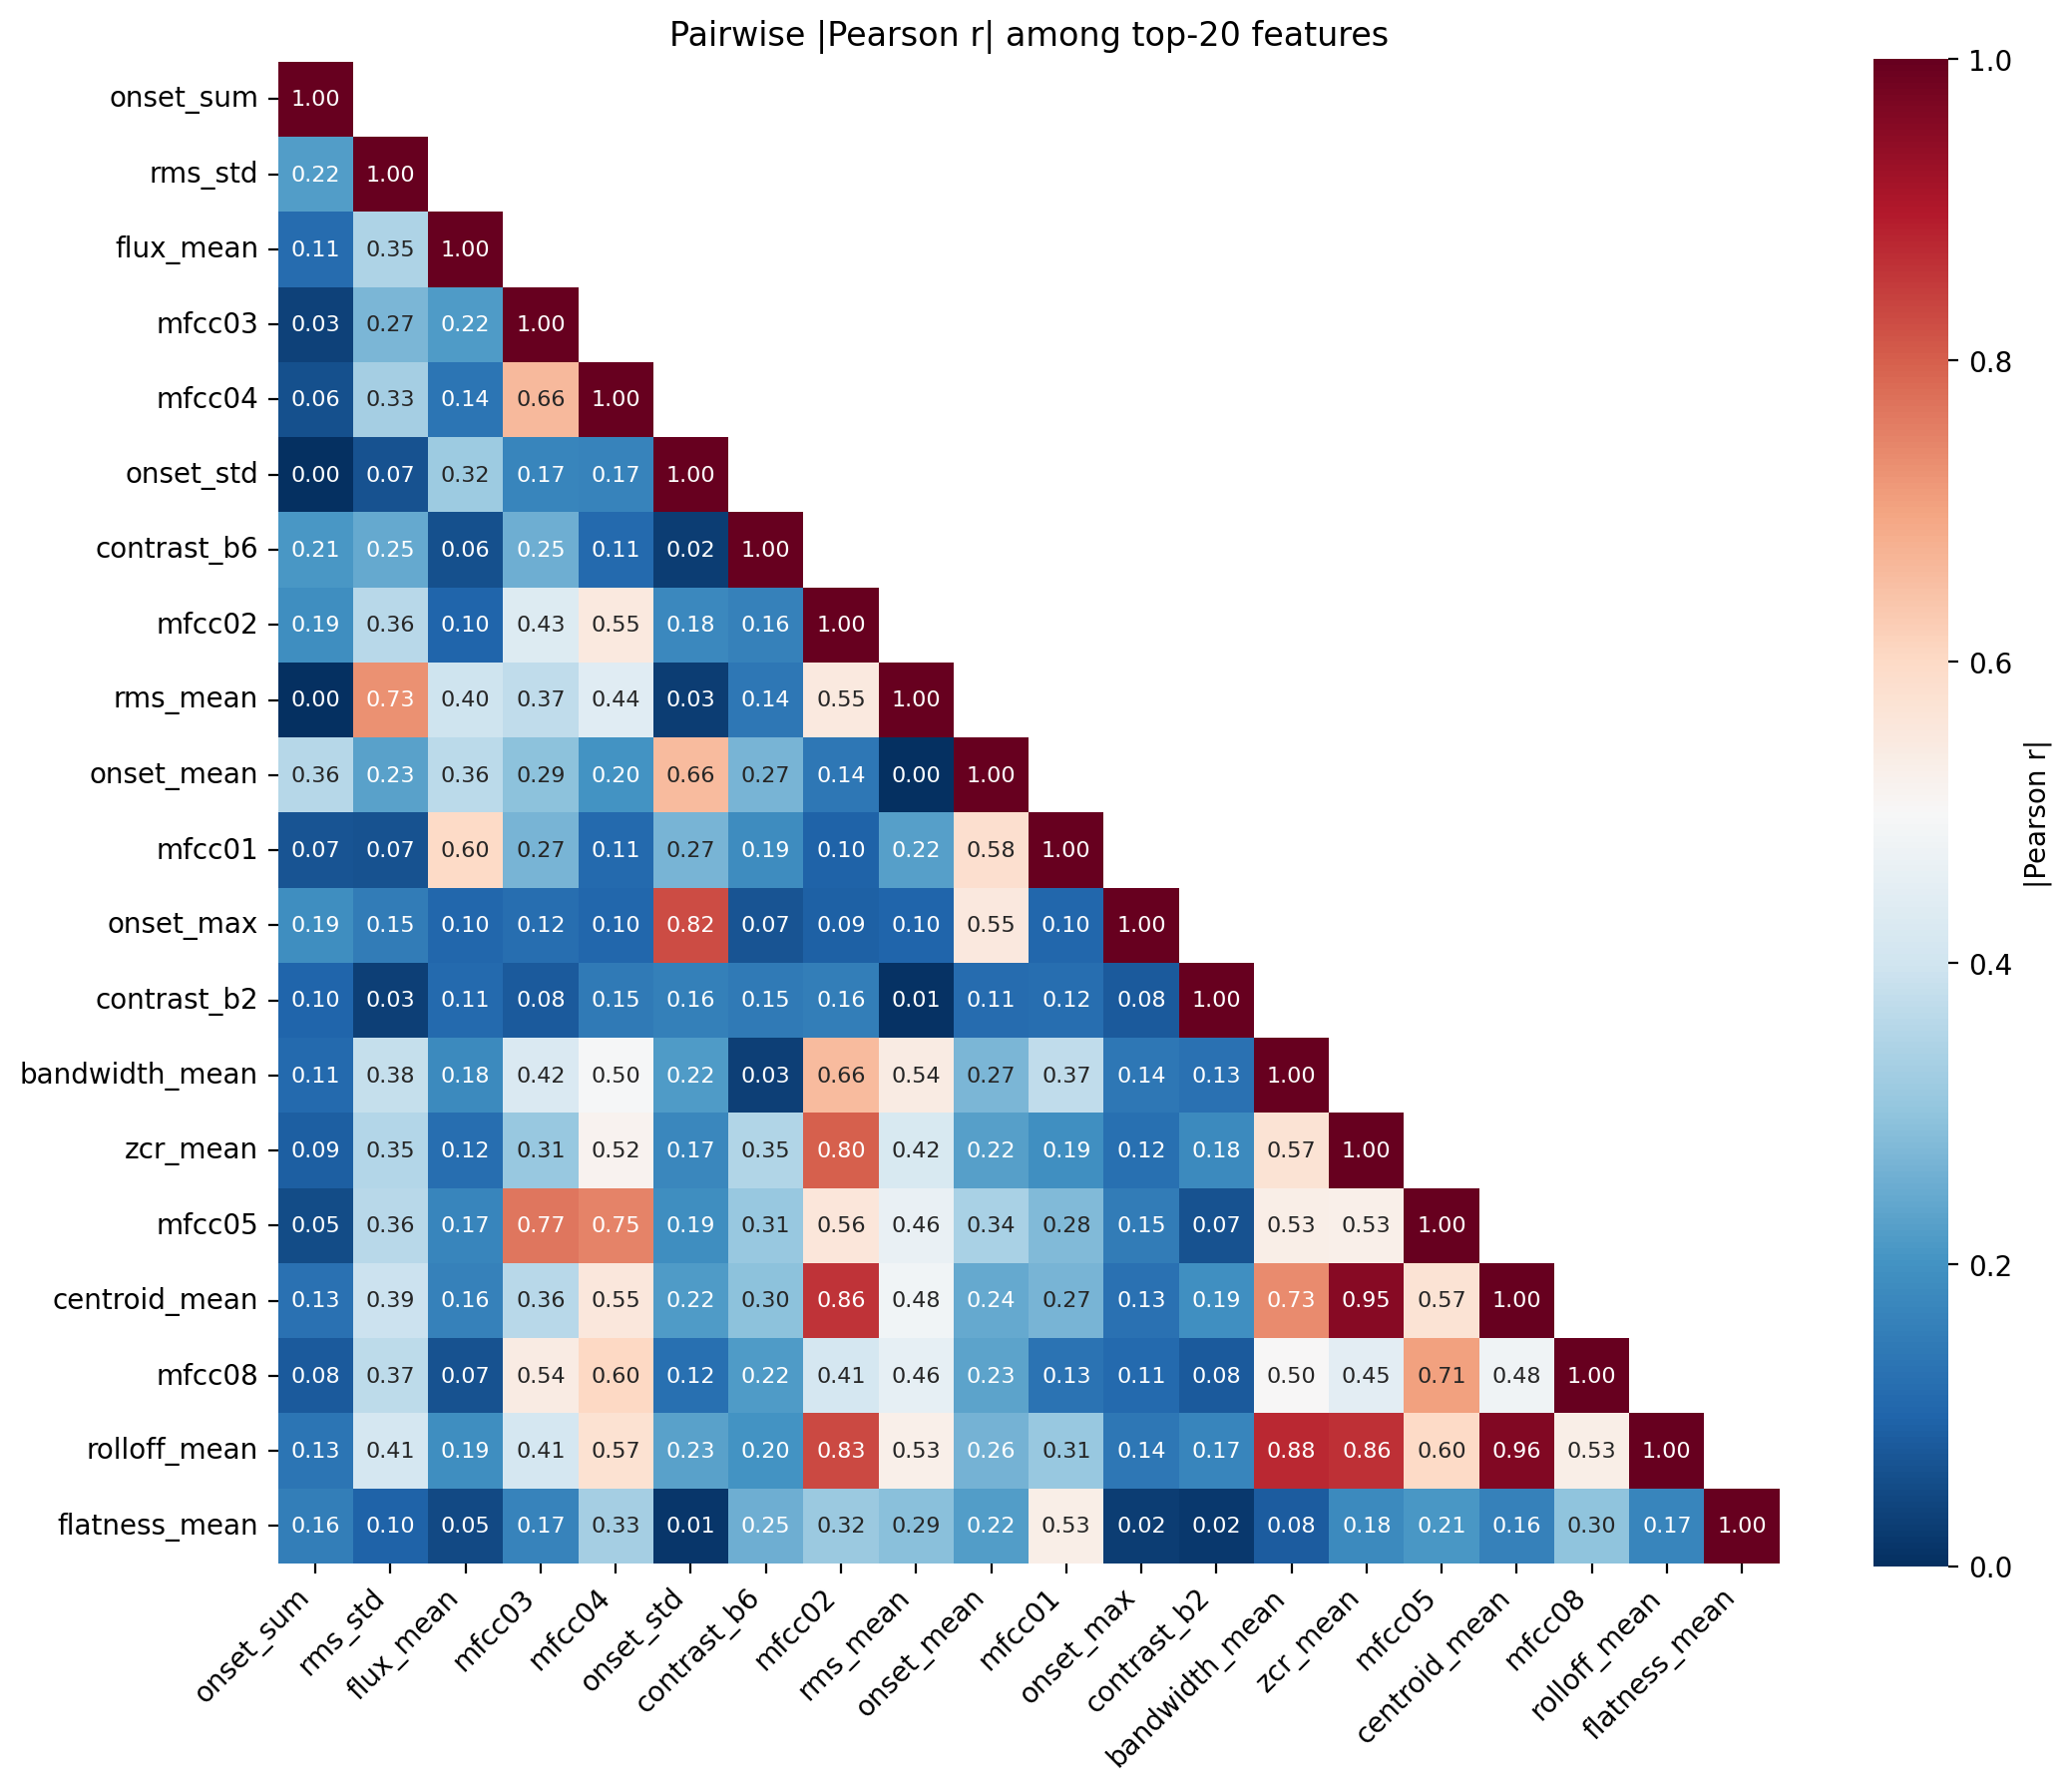

HIGH CORRELATIONS within top-20 (|r| >= 0.7):
  centroid_mean        x rolloff_mean          |r| = 0.961
  zcr_mean             x centroid_mean         |r| = 0.953
  bandwidth_mean       x rolloff_mean          |r| = 0.878
  zcr_mean             x rolloff_mean          |r| = 0.864
  mfcc02               x centroid_mean         |r| = 0.863
  mfcc02               x rolloff_mean          |r| = 0.829
  onset_std            x onset_max             |r| = 0.825
  mfcc02               x zcr_mean              |r| = 0.798
  mfcc03               x mfcc05                |r| = 0.768
  mfcc04               x mfcc05                |r| = 0.749
  bandwidth_mean       x centroid_mean         |r| = 0.735
  rms_std              x rms_mean              |r| = 0.727
  mfcc05               x mfcc08                |r| = 0.706


In [10]:
top20_feats = importance_df.head(20)['feature'].tolist()
corr = df_filled[top20_feats].corr().abs()

fig, ax = plt.subplots(figsize=(11, 9), dpi=200)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=0, vmax=1, square=True, mask=mask,
            cbar_kws={'label': '|Pearson r|'}, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Pairwise |Pearson r| among top-20 features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/top20_correlation.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Report high correlations (|r| >= 0.7)
pairs = []
for i in range(len(top20_feats)):
    for j in range(i+1, len(top20_feats)):
        r = corr.iloc[i, j]
        if r >= 0.7:
            pairs.append((top20_feats[i], top20_feats[j], r))
pairs.sort(key=lambda p: -p[2])

print('HIGH CORRELATIONS within top-20 (|r| >= 0.7):')
for a, b, r in pairs:
    print(f'  {a:20s} x {b:20s}  |r| = {r:.3f}')


## 10. Summary by feature group

In [11]:
feature_groups = {
    'MFCC'                : [f for f in feature_cols if f.startswith('mfcc')],
    'RMS'                 : [f for f in feature_cols if f.startswith('rms_')],
    'Spectral shape'      : ['zcr_mean', 'centroid_mean', 'bandwidth_mean',
                             'rolloff_mean', 'flatness_mean'],
    'Spectral flux'       : ['flux_mean'],
    'Spectral contrast'   : [f for f in feature_cols if f.startswith('contrast_b')],
    'Onset (waveform)'    : ['onset_mean', 'onset_std', 'onset_max', 'onset_sum'],
    'Attack'              : ['attack_time', 'attack_slope'],
    'PHER (hpi_ratio)'    : ['hpi_ratio'],
}

# Keep only features that actually exist
feature_groups = {g: [f for f in fs if f in feature_cols]
                  for g, fs in feature_groups.items()}

rows = []
for g, fs in feature_groups.items():
    rows.append({
        'group'        : g,
        'n_features'   : len(fs),
        'sum_imp_mean' : importance_df.set_index('feature').loc[fs, 'imp_mean'].sum(),
        'mean_imp_mean': importance_df.set_index('feature').loc[fs, 'imp_mean'].mean(),
        'best_rank'    : int(importance_df.set_index('feature').loc[fs, 'rank_mean'].min()),
    })
groups_df = pd.DataFrame(rows).sort_values('sum_imp_mean', ascending=False)
groups_df.to_csv(f'{OUT_DIR}/group_importance.csv', index=False)

print(groups_df.to_string(index=False))


            group  n_features  sum_imp_mean  mean_imp_mean  best_rank
             MFCC          20      2.273445       0.113672          3
 Onset (waveform)           4      1.165525       0.291381          1
Spectral contrast           7      0.875933       0.125133          7
   Spectral shape           5      0.703539       0.140708         13
              RMS           2      0.526812       0.263406          2
    Spectral flux           1      0.259854       0.259854          3
           Attack           2      0.164885       0.082442         28
 PHER (hpi_ratio)           1      0.069702       0.069702         38


## 11. Export top-20 and top-10 feature lists
These lists are the input for the 20-feature and 10-feature training notebooks.

In [12]:
top20 = importance_df.head(20)['feature'].tolist()
top10 = importance_df.head(10)['feature'].tolist()

pd.DataFrame({'feature': top20}).to_csv(
    f'{OUT_DIR}/top20_list.csv', index=False)
pd.DataFrame({'feature': top10}).to_csv(
    f'{OUT_DIR}/top10_list.csv', index=False)

print('TOP-20 (in order):')
for i, f in enumerate(top20, 1):
    print(f'  {i:2d}. {f}')

print('\nTOP-10 (in order):')
for i, f in enumerate(top10, 1):
    print(f'  {i:2d}. {f}')

print(f'\nSaved to {OUT_DIR}:')
for f in ['top20_list.csv', 'top10_list.csv',
          'feature_importance_mean.csv', 'feature_importance_per_run.csv',
          'group_importance.csv', 'ranking_stability_spearman.png',
          'top20_importance_bar.png', 'class_importance_raw.png',
          'class_importance_rownorm.png', 'top20_correlation.png']:
    print(f'  {f}')


TOP-20 (in order):
   1. onset_sum
   2. rms_std
   3. flux_mean
   4. mfcc03
   5. mfcc04
   6. onset_std
   7. contrast_b6
   8. mfcc02
   9. rms_mean
  10. onset_mean
  11. mfcc01
  12. onset_max
  13. contrast_b2
  14. bandwidth_mean
  15. zcr_mean
  16. mfcc05
  17. centroid_mean
  18. mfcc08
  19. rolloff_mean
  20. flatness_mean

TOP-10 (in order):
   1. onset_sum
   2. rms_std
   3. flux_mean
   4. mfcc03
   5. mfcc04
   6. onset_std
   7. contrast_b6
   8. mfcc02
   9. rms_mean
  10. onset_mean

Saved to /content/drive/MyDrive/SavedModels/42feats_runs/importance:
  top20_list.csv
  top10_list.csv
  feature_importance_mean.csv
  feature_importance_per_run.csv
  group_importance.csv
  ranking_stability_spearman.png
  top20_importance_bar.png
  class_importance_raw.png
  class_importance_rownorm.png
  top20_correlation.png


## Done

**What to paste back to the conversation:**
1. The full **FULL RANKING** table from Section 5
2. The **Mean / Min / Max off-diagonal ρ** from Section 6
3. The list of **HIGH CORRELATIONS** from Section 9
4. The **feature-group summary** from Section 10
5. The **top-20 and top-10** lists from Section 11

With these in hand we can (a) finalise the top-20 and top-10 feature lists, (b) write the revised Section 2.1 (Feature Importance Analysis) of the paper, and (c) build the 20-feature and 10-feature training notebooks.
